# Example on non-linear relationship

Suppose we are interested in studying the relationship between future realized volatility and the VIX

$$
RV_{t\to t+h}=\beta_0+\beta_1\,VIX_t+\varepsilon_t\
$$

but we fear that the relation ship is not linear. Instead, we estimate:

$$
RV_{t\to t+h}=\beta_0+ \sum_{i=1}^I\beta_i\,VIX_t^i+\varepsilon_t;\quad I=\{1, 2, 5\}
$$

## 0. Required packages

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

## 1. Retrieve and prepare data

We can use the `yfinance` Python package, which takes the following arguments:

- ticker
- start/end

where the S&P500 and VIX tickers are `^GSPC`, `^VIX`, respectively. 

The realized volatility between $t$ and $t+h$ is constructed using the next 22 trading days (one month) volatility of S&P500 returns.

In [3]:
start = "1990-01-01"
end = "2025-01-01"

# 1) Download daily S&P 500 and VIX levels
px = yf.download(["^GSPC", "^VIX"], start=start, end=end, auto_adjust=True, progress=False)["Close"].dropna()
px.columns = ["SPX", "VIX"]

# 2) Daily log returns for S&P 500
ret = np.log(px["SPX"]).diff()

# 3) Forward realized vol over next ~1 month (22 trading days), annualized
h = 22
rv_fwd = ret.shift(-1).rolling(h).std() * np.sqrt(252)
rv_fwd.name = "RV_FWD"

# 4) Dataset (use VIX as decimal: 20 -> 0.20)
df = pd.concat([px["VIX"], rv_fwd], axis=1).dropna()
df["VIX_DEC"] = df["VIX"] / 100.0

## 2. Estimate the model

We estimate the model using OLS and correct for heteroskedasticity and autocorrelation up to 5 lags. For comparability, we estimate three versions:
1. Linear model
2. Quadratic model (degree of the polynomial = 2)
3. Polynomial of degree 5

In [4]:
# Create polynomial terms up to degree 5
for k in range(2, 6):
    df[f"VIX{k}"] = df["VIX_DEC"] ** k

maxlags = 5  # HAC lags (daily)

# 5) Degree 1 (linear)
X1 = sm.add_constant(df[["VIX_DEC"]])
m1 = sm.OLS(df["RV_FWD"], X1).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
print("\n=== Degree 1: RV_FWD ~ VIX ===")
print(m1.summary())

# 6) Degree 2 (quadratic)
X2 = sm.add_constant(df[["VIX_DEC", "VIX2"]])
m2 = sm.OLS(df["RV_FWD"], X2).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
print("\n=== Degree 2: RV_FWD ~ VIX + VIX^2 ===")
print(m2.summary())

# 7) Degree 5
X5 = sm.add_constant(df[["VIX_DEC", "VIX2", "VIX3", "VIX4", "VIX5"]])
m5 = sm.OLS(df["RV_FWD"], X5).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})
print("\n=== Degree 5: RV_FWD ~ VIX + ... + VIX^5 ===")
print(m5.summary())

# 8) Plot: data + fitted curves (degrees 1, 2, 5)
v_grid = np.linspace(df["VIX_DEC"].min(), df["VIX_DEC"].max(), 300)

Xg1 = sm.add_constant(pd.DataFrame({"VIX_DEC": v_grid}))
y1 = m1.predict(Xg1)

Xg2 = sm.add_constant(pd.DataFrame({"VIX_DEC": v_grid, "VIX2": v_grid**2}))
y2 = m2.predict(Xg2)

Xg5 = pd.DataFrame({"VIX_DEC": v_grid})
for k in range(2, 6):
    Xg5[f"VIX{k}"] = v_grid**k
Xg5 = sm.add_constant(Xg5)
y5 = m5.predict(Xg5)


=== Degree 1: RV_FWD ~ VIX ===
                            OLS Regression Results                            
Dep. Variable:                 RV_FWD   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     983.0
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          1.21e-204
Time:                        15:08:25   Log-Likelihood:                 14607.
No. Observations:                8795   AIC:                        -2.921e+04
Df Residuals:                    8793   BIC:                        -2.920e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.053

## 3. Plot

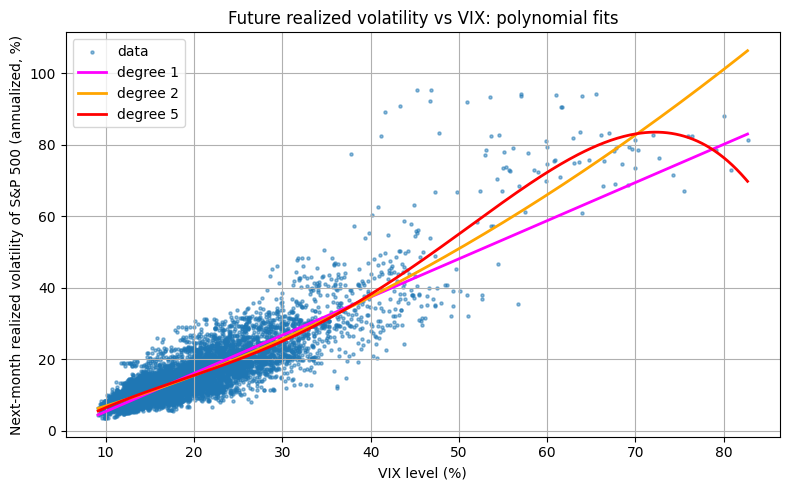

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df["VIX_DEC"] * 100, df["RV_FWD"] * 100, alpha=0.50, s=5, label="data")
plt.plot(v_grid * 100, y1 * 100, linewidth=2, label="degree 1", color='magenta')
plt.plot(v_grid * 100, y2 * 100, linewidth=2, label="degree 2", color='orange')
plt.plot(v_grid * 100, y5 * 100, linewidth=2, label="degree 5", color='red')
plt.xlabel("VIX level (%)")
plt.ylabel("Next-month realized volatility of S&P 500 (annualized, %)")
plt.title("Future realized volatility vs VIX: polynomial fits")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Conditioning value

$$
\kappa(X) = \sqrt{\frac{\lambda_{max}(X^\prime X)}{\lambda_{min}(X^\prime X)}}
$$

i.e. squared root of the ratio of the largest and lowest eigenvalue.

- If close to one $\rightarrow$ all directions are informative
- If large $\rightarrow$ at least one direction is not informative

In [10]:
eig2 = np.linalg.eigvalsh(X2.T @ X2)
eig5 = np.linalg.eigvalsh(X5.T @ X5)

print(f"Conditioning number (degree 2): {np.sqrt(eig2.max() / eig2.min())}")
print(f"Conditioning number (degree 5): {np.sqrt(eig5.max() / eig5.min())}")

Conditioning number (degree 2): 79.65857161510262
Conditioning number (degree 5): 29240.295190802208
